# Lecture 8: Linear Optimization

[![Open In Colab](images/colab-badge.svg)](https://colab.research.google.com/github/UvA-SSO/simopt-lecture-notes/blob/main/notebooks/lecture8_linear-optimization.ipynb)

This notebook introduces linear optimization (LO), also called linear programming. It is
a widely used optimization framework in practice: efficient solvers exist that are
guaranteed to find the optimum even for problems with thousands of variables and
constraints. We introduce it through an example, model it, solve it in Python with
[pulp](https://coin-or.github.io/pulp/), look at what the solver is doing both graphically
and algebraically, and see what can go wrong.

**Learning outcomes**

On completion of this notebook, you will be able to:

- formulate a real-life decision problem as an LO model (decision variables, objective,
  constraints);
- implement an LO model in pulp, both directly and with the data kept separate from the
  model;
- understand the intuition behind the simplex method;
- interpret an LO solution both graphically and algebraically;
- recognize infeasibility and unboundedness in pulp's solve status.

## A Motivating Problem: Optimal Product Mix

A workshop makes two products, $x$ and $y$, from two limited resources: oak panels and
assembly hours. Producing one unit of $x$ uses 1 oak panel and 1 assembly hour; one unit
of $y$ uses no oak panels and 2 assembly hours. Product $x$ earns a profit of 3 per unit,
product $y$ a profit of 5 per unit.

| | profit | oak panels needed | assembly hours needed |
|---|---|---|---|
| $x$ | 3 | 1 | 1 |
| $y$ | 5 | 0 | 2 |

There are 6 oak panels and 15 assembly hours available this week. Which product mix
maximizes profit?

(modeling-approach)=
## The Modeling Approach

We follow the same four steps for every problem in this course:

1. **study the problem** in detail (done above);
2. **define the decision variables**: let $x$ and $y$ be the quantities of the two
   products produced;
3. **define the objective**: maximize profit, $3x + 5y$;
4. **define the constraints**: the oak-panel usage, $x$, cannot exceed 6; the
   assembly-hour usage, $x + 2y$, cannot exceed 15; and $x, y \ge 0$.

In mathematical form:

$$
\begin{aligned}
\text{maximize} \quad & 3x + 5y & \text{(objective)} \\
\text{subject to} \quad & x \le 6 & \text{(oak panels)} \\
& x + 2y \le 15 & \text{(assembly hours)} \\
& x, y \ge 0.
\end{aligned}
$$

The objective and all constraints are linear functions of the decision variables
$(x, y)$, hence the name *linear* optimization.

## Solving the Model Directly in pulp

For a small, one-off model like this, the fastest way from model to answer is to write it
in pulp exactly as it appears above, with the numbers typed directly into the variable
bounds and constraints. We walk through it step by step; each step maps onto one of the
[four modeling steps](#modeling-approach) above.

### Import pulp

[pulp](https://coin-or.github.io/pulp/) is the Python package we use to build and solve
LO (and, later, ILO) models.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

try:
    import pulp
except ModuleNotFoundError:  # pulp is not preinstalled on Google Colab
    import subprocess
    import sys

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pulp"], check=True)
    import pulp

### Introduce the LP Problem

An `LpProblem` is pulp's container for a model: give it a name and a `sense`
(`LpMaximize` or `LpMinimize`).

In [ ]:
product_mix = pulp.LpProblem(name="product_mix", sense=pulp.LpMaximize)

### Specify the Decision Variables (step 2)

Each decision variable becomes an `LpVariable`; `lowBound=0` encodes $x, y \ge 0$.

In [ ]:
x = pulp.LpVariable(name="x", lowBound=0)
y = pulp.LpVariable(name="y", lowBound=0)

### Specify the Objective Function (step 3)

Add the objective to the problem with `+=`; the optional string names it for pulp's
output.

In [ ]:
product_mix += 3 * x + 5 * y, "profit"

### Specify the Constraints (step 4)

Constraints are added the same way, one `+=` call per constraint.

In [ ]:
product_mix += x <= 6, "oak_panels"
product_mix += x + 2 * y <= 15, "assembly_hours"

### Solve and Check the Results

`.solve()` runs the solver; `LpStatus` reports whether it found an optimum, and
`.value()` reads off the variables and the objective.

In [2]:
product_mix.solve(pulp.PULP_CBC_CMD(msg=False))
print("status:", pulp.LpStatus[product_mix.status])
print(f"x = {x.value()}, y = {y.value()}")
print("optimal profit:", product_mix.objective.value())

status: Optimal
x = 5.0, y = 2.5
optimal profit: 17.5


## Separating Data from the Model

The direct version above hardcodes every number into the model itself, which is fine for
a problem you solve once. It breaks down as soon as you want to re-solve for different
data (more products, different resource limits) or reuse the same model code elsewhere:
every number would have to be found and edited inside the model-building code, which is
slow and error-prone. The fix is to keep the instance *data* in plain Python structures,
separate from the *model*-building code, and build the model from that data:

In [3]:
profit = {"x": 3, "y": 5}
resource_use = {  # resource_use[r][p]: units of resource r per unit of product p
    "oak panels": {"x": 1, "y": 0},
    "assembly hours": {"x": 1, "y": 2},
}
available = {"oak panels": 6, "assembly hours": 15}
products = list(profit)

product_mix = pulp.LpProblem(name="product_mix", sense=pulp.LpMaximize)
q = {p: pulp.LpVariable(name=p, lowBound=0) for p in products}

product_mix += pulp.lpSum(profit[p] * q[p] for p in products), "profit"
for r, cap in available.items():
    product_mix += (
        pulp.lpSum(resource_use[r][p] * q[p] for p in products) <= cap,
        r.replace(" ", "_"),
    )

product_mix.solve(pulp.PULP_CBC_CMD(msg=False))
print("status:", pulp.LpStatus[product_mix.status])
print("optimal mix:", {p: q[p].value() for p in products})
print("optimal profit:", product_mix.objective.value())

status: Optimal
optimal mix: {'x': 5.0, 'y': 2.5}
optimal profit: 17.5


The model-building code (the `for` loop and the `pulp.lpSum` calls) no longer mentions 3,
5, 6, or 15 anywhere: it works unchanged for any number of products and resources, as
long as `profit`, `resource_use`, and `available` describe them. This is the pattern we
use for every larger model from here on, and it is also the discipline behind the
algebraic modeling languages (AMLs) introduced in
[Modeling Tools and Solvers](lecture10_modeling-tools.ipynb).

(larger-lo-example)=
## A Larger Example in pulp

The same three ingredients, and the same data/model split, scale to any size. Suppose the
workshop adds a third product, $z$, that uses 2 oak panels and 1 assembly hour per unit
and earns a profit of 4 per unit, and that both resources become a bit more plentiful: 9
oak panels and 20 assembly hours. Only the *data* changes; the model-building code stays
exactly the same as in the previous section:

In [4]:
profit = {"x": 3, "y": 5, "z": 4}
resource_use = {  # resource_use[r][p]: units of resource r per unit of product p
    "oak panels": {"x": 1, "y": 0, "z": 2},
    "assembly hours": {"x": 1, "y": 2, "z": 1},
}
available = {"oak panels": 9, "assembly hours": 20}
products = list(profit)

larger_lo = pulp.LpProblem(name="larger_lo", sense=pulp.LpMaximize)
q = {p: pulp.LpVariable(name=p, lowBound=0) for p in products}

larger_lo += pulp.lpSum(profit[p] * q[p] for p in products), "profit"
for r, cap in available.items():
    larger_lo += (
        pulp.lpSum(resource_use[r][p] * q[p] for p in products) <= cap,
        r.replace(" ", "_"),
    )

larger_lo.solve(pulp.PULP_CBC_CMD(msg=False))
print("status:", pulp.LpStatus[larger_lo.status])
print("optimal mix:", {p: q[p].value() for p in products})
print("optimal profit:", larger_lo.objective.value())

optimal solution: [0.0, 0.66666667, 4.0]
optimal objective: 34.66666668


The model-building code is identical to the two-product case; only the data changed.

## A Graphical View

With only two decision variables we can draw the product-mix problem. Each constraint is
a line; the feasible region is the set of points satisfying all of them at once. Because
both the constraints and the objective are linear, the objective-value contour lines are
straight and parallel. Sliding one in the direction of increasing profit, the last
feasible point it touches is an optimal solution, and it is always a corner of the
feasible region.

:::{exercise}
:label: ex-6-1

Derive by hand the corner points of the feasible region of the product-mix problem above,
evaluate the objective at each, and check which one pulp found.
:::

The code below only produces the figure; reproducing it is not itself something you need
to learn, so feel free to skip straight to the plot.

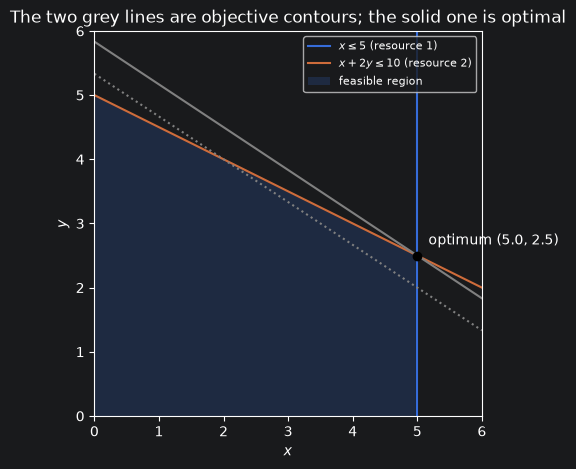

In [5]:
x_grid = np.linspace(0, 8, 200)
plt.figure(figsize=(5, 5))
plt.axvline(6, color="C0", label=r"$x \leq 6$ (oak panels)")
plt.plot(x_grid, (15 - x_grid) / 2, color="C1", label=r"$x + 2y \leq 15$ (assembly hours)")
plt.fill_between(
    x_grid, 0, (15 - x_grid) / 2, where=(x_grid <= 6), alpha=0.2, label="feasible region"
)

x_opt, y_opt = q["x"].value(), q["y"].value()
for level, style in [(25, ":"), (product_mix.objective.value(), "-")]:
    plt.plot(x_grid, (level - 3 * x_grid) / 5, style, color="grey")
plt.plot(x_opt, y_opt, "ko")
plt.annotate(
    f"optimum ({x_opt:.1f}, {y_opt:.1f})", (x_opt, y_opt), textcoords="offset points", xytext=(8, 8)
)

plt.xlim(0, 8)
plt.ylim(0, 8)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend(loc="upper right", fontsize=8)
plt.title("The two grey lines are objective contours; the solid one is optimal")
plt.show()

The dotted grey line (profit 25) still has feasible points but we can do better; sliding
it out until it just leaves the feasible region gives the solid line, which touches the
region only at the corner where the two resource constraints meet: the optimum pulp
reported above.

:::{exercise}
:label: ex-lo-what-if

Suppose the assembly-hours availability increased from 15 to 20. Which line in the plot
moves, and in which direction would you expect the optimum to shift? Check your answer by
re-solving with pulp.
:::

## An Algebraic View

The same optimum can be understood without a picture. Turn each "$\le$" constraint into
an equality by adding a non-negative slack variable, the amount of the resource left
unused:

$$
\begin{aligned}
x \le 6 \\
x + 2y \le 15 \\
x, y \ge 0
\end{aligned}
\quad\Leftrightarrow\quad
\begin{aligned}
x + s_1 &= 6 \\
x + 2y + s_2 &= 15 \\
x, y, s_1, s_2 &\ge 0
\end{aligned}
$$

There are now 2 equations and 4 variables. As a rule, a system of $k$ independent linear
equations in $k$ unknowns has exactly one solution, so if we set any 2 of the 4 variables
to zero the other 2 are determined. Each such choice corresponds to a corner of the
feasible region (some combinations give a negative value and are infeasible; those are
corners of the lines' intersections that lie outside the region). The corners here are:

- $(x, y, s_1, s_2) = (0, 0, 6, 15)$: the origin;
- $(6, 0, 0, 9)$: oak panels fully used;
- $(0, 7.5, 6, 0)$: assembly hours fully used;
- $(6, 4.5, 0, 0)$: both resource constraints tight, the optimum.

The simplex algorithm (G.B. Dantzig, 1947), which pulp's default solver uses for LO, hops
from corner to neighbouring corner, each time to one with a better objective value, and
stops when no neighbouring corner is better. Why is that enough to guarantee the *global*
optimum? Because the feasible region of an LO problem is a convex polyhedron: a shape with
flat faces and no hidden hills. If every neighbour of your current corner is worse, there
is nowhere higher to go, since reaching a higher point would require the boundary to
curve, and linear constraints never curve. So for LO, a local optimum is automatically a
global optimum.

:::{note} History of Linear Optimization
Several researchers formulated linear optimization problems, but it was G.B. Dantzig
(1914–2005) who invented the simplex algorithm in 1947. Until recently the field was
commonly called *linear programming*. Its dynamic, random counterpart is *dynamic
programming*, developed by R.E. Bellman (1920–1984); the division between deterministic
and random problems is still very visible in operations research.
:::

## Three Possible Outcomes

Not every LO problem has an optimal solution. There are exactly three possibilities:

1. **an optimal solution exists** (the case above);
2. **unbounded**: solutions of arbitrarily large objective value exist. For the
   product-mix problem this happens if we drop the assembly-hours constraint, since
   nothing else limits $y$, and we could then make unlimited units of it;
3. **infeasible**: no point satisfies all constraints. This happens if, for example, a
   customer contract forces $y \ge 9$ while the assembly-hours constraint allows at most
   $y = 7.5$.

pulp reports these as the `LpStatus` values `"Unbounded"` and `"Infeasible"` instead of
`"Optimal"`. [](#fig-lo-degenerate) shows both situations schematically.

:::{figure} images/lecture8_fig6.2.png
:label: fig-lo-degenerate

An unbounded (left) and an infeasible (right) LO problem.
:::

The same two problems, this time solved with pulp:

In [6]:
unbounded_lp = pulp.LpProblem(name="unbounded_example", sense=pulp.LpMaximize)
x = pulp.LpVariable(name="x", lowBound=0)
y = pulp.LpVariable(name="y", lowBound=0)
unbounded_lp += 3 * x + 5 * y
unbounded_lp += x <= 6  # the assembly-hours constraint is dropped

unbounded_lp.solve(pulp.PULP_CBC_CMD(msg=False))
print("status:", pulp.LpStatus[unbounded_lp.status])

status: Unbounded


In [7]:
infeasible_lp = pulp.LpProblem(name="infeasible_example", sense=pulp.LpMaximize)
x = pulp.LpVariable(name="x", lowBound=0)
y = pulp.LpVariable(name="y", lowBound=0)
infeasible_lp += 3 * x + 5 * y
infeasible_lp += x <= 6
infeasible_lp += x + 2 * y <= 15
infeasible_lp += y >= 9  # the customer contract

infeasible_lp.solve(pulp.PULP_CBC_CMD(msg=False))
print("status:", pulp.LpStatus[infeasible_lp.status])

status: Infeasible


:::{exercise}
:label: ex-6-3

Change the customer contract above to require $x \ge 7$ instead (impossible since the
oak-panel constraint caps $x$ at 6), and confirm pulp still reports `"Infeasible"`.
:::

(project-planning)=
## Another Application: Project Planning

(graphs-intro)=
A graph is a network of *nodes* (also called vertices) connected by *edges*; a directed
edge is called an *arc*. Many problems are naturally expressed on graphs. One is project
planning: a project has activities (nodes), each with a duration, and precedence
relations (arcs). An activity can only start once its predecessors are finished (you
cannot roof a house before the walls are up).

| activity | duration | must follow |
|---|---|---|
| A | 3 | none |
| B | 4 | none |
| C | 2 | A |
| D | 5 | A, B |
| E | 1 | C, D |
| F | 3 | D |

Let $x_i$ be the finish time of activity $i$. If $i$ precedes $j$ then
$x_i + d_j \le x_j$, where $d_j$ is the duration of $j$; also $x_i \ge d_i$. We want the
time when *all* activities are finished, $\max_i x_i$. That maximum is not linear, but we
can introduce a variable $z \ge x_i$ for all $i$ and minimize $z$: the optimization will
push $z$ down to exactly the largest finish time. This "min-max" trick reappears
throughout the course.

$$
\begin{aligned}
\text{minimize} \quad & z \\
\text{subject to} \quad & z \ge x_i \text{ for all activities } i \\
& x_i + d_j \le x_j \text{ if } i \text{ precedes } j \\
& x_i \ge d_i \text{ for all activities } i.
\end{aligned}
$$

In [8]:
duration = {"A": 3, "B": 4, "C": 2, "D": 5, "E": 1, "F": 3}
precedences = [("A", "C"), ("A", "D"), ("B", "D"), ("C", "E"), ("D", "E"), ("D", "F")]

In [9]:
project = pulp.LpProblem(name="project_planning", sense=pulp.LpMinimize)
finish = {a: pulp.LpVariable(name=f"x_{a}", lowBound=duration[a]) for a in duration}
makespan = pulp.LpVariable(name="z", lowBound=0)

for a in duration:
    project += makespan >= finish[a]
for before, after in precedences:
    project += finish[before] + duration[after] <= finish[after]

# minimize z; the tiny extra term only breaks ties, so activities that have slack still get
# their *earliest* finish time reported instead of an arbitrary one consistent with z.
project += makespan + 1e-4 * pulp.lpSum(finish[a] for a in duration)

project.solve(pulp.PULP_CBC_CMD(msg=False))
print("earliest finish times:", {a: round(finish[a].value(), 2) for a in duration})
print("project finish time (makespan):", makespan.value())

earliest finish times: {'A': 3.0, 'B': 4.0, 'C': 5.0, 'D': 9.0, 'E': 10.0, 'F': 12.0}
project finish time (makespan): 12.0


The project-planning model above (activities `A`–`F`, the `duration` dict and
`precedences` list) is referred to from later notebooks. The finish time can also be
found by a direct algorithm without LO, and that algorithm extends to *random* durations,
which matters because durations are often hard to predict, one reason IT projects
overrun.

:::{exercise}
:label: ex-6-7

Find the project finish time by hand: repeatedly take the activity whose predecessors are
all finished and give it the earliest possible finish time. Check you get the same
makespan as pulp.
:::

## References

- Koole, G. (2019). *An Introduction to Business Analytics*. §6.1 "Problem Formulation",
  §6.3 "Example LO Problems" (project planning).